# Ver.5 Dynamic GLM-HMM — κ と day 別遷移行列（VG1GC-66）

ノート18は著者実装の `'standard'` と `'partial'`（σ=1）までで、κ と day 別の遷移行列は学習していない。このノートは同じ公開実装 [lenca56/dynamic_glmhmm](https://github.com/lenca56/dynamic_glmhmm) の `'dynamic'` まで進める。自前実装は使わない。

day \(s\) の遷移行列は、その day の期待遷移回数 \(n^s\) と、`'partial'` で得た全 day 共通の遷移行列 \(A\) の加重平均になる。

\[
P^s_{ij} = \frac{n^s_{ij} + \kappa A_{ij}}{n^s_i + \kappa}
\]

κ が大きいほど \(P^s\) は \(A\) に寄り、κ=∞ が `'partial'` そのもの。day どうしは互いを参照しない。

| 固定するもの | 値 |
| :--- | :--- |
| 個体・入力 | `VG1GC-66`、修正1後の `[x_bias, x_hist_z, x_rew_z]`、観測 `yA`（1=No Reaction） |
| σ | 1（全状態・全列共通。掃引しない） |
| π | 一様固定（`fit_init_states=False`） |
| K | 3。K=2 はこのノートでは走らせない |
| fold | 著者の `split_data(N, SESS, folds=5, blocks=10, random_state=1)` |

κ は test 対数尤度が最大、というだけでは選ばない。退化チェック（day 内位置の時計化、全日が同じセグメント順、吸収状態、NaN）を全 fold で通った κ のうち、test 対数尤度が最大のものを採る。κ=0 はグリッドに残すが、チェックを落ちたら選ばない。

## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())

cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
DYN_REPO = Path('external') / 'dynamic_glmhmm'
if not (DYN_REPO / 'code' / 'dynamic_glmhmm.py').exists():
    DYN_REPO.parent.mkdir(parents=True, exist_ok=True)
    os.system(f'git clone --depth 1 https://github.com/lenca56/dynamic_glmhmm {DYN_REPO}')
if str((DYN_REPO / 'code').resolve()) not in sys.path:
    sys.path.insert(0, str((DYN_REPO / 'code').resolve()))

import dynamic_glmhmm
from utils import reshapeSigma, reshapeP_M1_to_M2
from analysis_utils import split_data, fit_eval_CV_dynamic_model
print('dynamic_glmhmm:', dynamic_glmhmm.__file__)

dynamic_glmhmm: /mnt/c/Users/dmasu/braidyn-bc/external/dynamic_glmhmm/code/dynamic_glmhmm.py


In [3]:
import time, io as _io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})
from matplotlib import font_manager
for _fp in [Path('/mnt/c/Windows/Fonts/YuGothM.ttc'), Path('/mnt/c/Windows/Fonts/meiryo.ttc'),
            Path('C:/Windows/Fonts/YuGothM.ttc'), Path('C:/Windows/Fonts/meiryo.ttc')]:
    if _fp.exists():
        font_manager.fontManager.addfont(str(_fp))
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(_fp)).get_name()
        break
print('font:', plt.rcParams['font.family'])

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT
ALPHA_REW = v4.ALPHA_REW
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
K, C = 3, 2
P_THRESHOLD = 0.80
BURN = 20
SIGMA = 1.0
FOLDS, BLOCKS, CV_SEED = 5, 10, 1
# 著者の fit_eval_CV_dynamic_model 既定。降順に温スタートし、末尾の枠が κ=∞。
ALPHA_LIST = [0, 1, 10, 100, 1000, 10000]
PAR_MAXITER, PAR_TOL = 200, 1e-3
DYN_MAXITER, DYN_TOL = 200, 1e-3
PRIOR_DIR_P = [10, 1]
# 退化の判定。ノート17の時計解は位置 0.101±0.080。
POS_MEAN_LO, POS_MEAN_HI, POS_SD_MAX = 0.25, 0.75, 0.15
POS_MIN_N = 30
ABSORB_DIAG = 0.999
STATE_COLORS = ['#4c72b0', '#dd8452', '#55a868']

CACHE_DIR = Path('data') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TRIALS = CACHE_DIR / f'ver5_trials_{MOUSE_ID}.pkl'
NB18_CACHE = CACHE_DIR / 'ver5_note18.pkl'
NB19_CACHE = CACHE_DIR / 'ver5_note19.pkl'

if CACHE_TRIALS.exists():
    trials_all = pd.read_pickle(CACHE_TRIALS)
    print('キャッシュから読み込み:', CACHE_TRIALS)
else:
    trials_all = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)['trials']
    trials_all.to_pickle(CACHE_TRIALS)

NB18 = pd.read_pickle(NB18_CACHE)
for key in ('std_fixed', 'final_fixed', 'sigA_fixed'):
    if key not in NB18:
        raise RuntimeError(f'ノート18のキャッシュに {key} が無い。先にノート18を実行する。')
NB19 = pd.read_pickle(NB19_CACHE) if NB19_CACHE.exists() else {}
print('note18 keys:', sorted(NB18))
print('note19 keys:', sorted(NB19) if NB19 else '(なし)')


def save_cache():
    pd.to_pickle(NB19, NB19_CACHE)


@contextlib.contextmanager
def quiet():
    buf = _io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield

環境: ローカル (WSL)


DATA_CSV_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


font: ['Yu Gothic']
キャッシュから読み込み: data/cache/ver5_trials_VG1GC-66.pkl


note18 keys: ['final_fixed', 'final_reset', 'sigA_fixed', 'sigA_reset', 'sigB_fixed', 'std_fixed', 'std_reset']
note19 keys: ['degen', 'dyn_folds', 'eligible', 'kappa_best', 'partial_folds']


## 1. 入力

ノート18と同じ修正1。History / Reward の指数フィルタを、各 day の先頭で 0 ではなく全 day プールの定常値から始める。fold 分割は `N` と `sessInd` だけで決まるのでノート18と同一になる。

In [4]:
def build_sequence(trials_all, h0=0.0, r0=0.0):
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = (g[g['trial_type'].isin(SOUND_TYPES)]
             .sort_values('t_start').reset_index(drop=True).copy())
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        h[0], r[0] = h0, r0
        for k in range(1, n):
            h[k] = a[k - 1] + ALPHA_ACT * h[k - 1]
            r[k] = rw[k - 1] + ALPHA_REW * r[k - 1]
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = 1 - a
        g['k'] = np.arange(n)
        out.append(g)
    tr = pd.concat(out, ignore_index=True)
    for c in ['x_hist', 'x_rew']:
        tr[c + '_z'] = (tr[c] - tr[c].mean()) / tr[c].std(ddof=0)
    return tr


INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']
tr_reset = build_sequence(trials_all)
H0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_hist'].mean())
R0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_rew'].mean())
tr = build_sequence(trials_all, H0, R0)

days = list(dict.fromkeys(tr['task_day'].tolist()))
X = tr[INPUT_COLS].to_numpy(dtype=float)
Y = tr['yA'].to_numpy().astype(int)
SESS = [0] + list(np.cumsum([int((tr['task_day'] == d).sum()) for d in days]))
N, D = X.shape
DAYS = days
DAY_LABELS = [str(d).replace('task-day', 'd') for d in DAYS]

presentTrain, presentTest = split_data(N, SESS, folds=FOLDS, blocks=BLOCKS, random_state=CV_SEED)
print(f'N={N}  D={D}  sessions={len(SESS)-1}  K={K}  sigma={SIGMA:g}')
print('day別試行数:', [SESS[i+1] - SESS[i] for i in range(len(SESS)-1)])
print('foldごとのtest試行数:', [int(pt.sum()) for pt in presentTest])

N=2359  D=3  sessions=14  K=3  sigma=1
day別試行数: [np.int64(76), np.int64(156), np.int64(103), np.int64(183), np.int64(318), np.int64(157), np.int64(153), np.int64(72), np.int64(155), np.int64(233), np.int64(233), np.int64(126), np.int64(231), np.int64(163)]
foldごとのtest試行数: [548, 510, 479, 402, 420]


## 2. fold ごとの `'partial'`（σ=1）

fold ごとの `'standard'` はノート18の `std_fixed['fits']` を初期値に使う。`'partial'` はノート18が test 対数尤度しか残していないので、`'standard'` 解から σ=1 へ直接学習し直す（18の σ 温スタートは再現しない）。全データの `'partial'` は `final_fixed['par']` をそのまま使う。

`'partial'` の遷移行列はディリクレ更新の分母が行ごとにずれて行和が 1 にならない。`'dynamic'` は大域遷移行列 \(A\) の行和が 1 から 1e-3 以上ずれると例外になるので、著者コードは変えず、渡す直前に行正規化する。

In [5]:
def as_global_P(P):
    '''N×K×K または K×K を、行和が1の K×K にする。'''
    A = np.asarray(P, dtype=float)
    if A.ndim == 3:
        A = A[0]
    A = A / A.sum(axis=1, keepdims=True)
    return A


def fit_partial_from_standard(x, y, present, p0, pi0, w0):
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    with quiet():
        p, pi, w, ll = m.fit(
            x, y, present, p0, pi0, w0,
            sigma=reshapeSigma(SIGMA, K, D), sessInd=SESS,
            maxIter=PAR_MAXITER, tol=PAR_TOL, L2penaltyW=0,
            priorDirP=PRIOR_DIR_P, model_type='partial', fit_init_states=False)
    ll = ll[ll != 0]
    _, ll_te, _ = m.evaluate(x, y, SESS, presentTest_for(present), p, pi, w)
    return dict(p=p, pi=pi, w=w, ll_train=float(ll[-1]), ll_test=float(ll_te), n_iter=int(len(ll)))


def presentTest_for(present):
    '''この fold の train マスクに対応する test マスク。'''
    for f in range(FOLDS):
        if np.array_equal(present, presentTrain[f]):
            return presentTest[f]
    raise RuntimeError('present が presentTrain のどれとも一致しない')


NB19.setdefault('partial_folds', {})
t0 = time.time()
for f in range(FOLDS):
    key = str(f)
    if key in NB19['partial_folds']:
        rec = NB19['partial_folds'][key]
        print(f'[cache] partial fold {f}: test LL {rec["ll_test"]:+.4f}')
        continue
    p0, pi0, w0 = NB18['std_fixed']['fits'][f]
    rec = fit_partial_from_standard(X, Y, presentTrain[f], p0, pi0, w0)
    A_raw = np.asarray(rec['p'][0], dtype=float)
    print(f'  partial fold {f}: train {rec["ll_train"]:.1f}  test {rec["ll_test"]:+.4f}'
          f'  iters {rec["n_iter"]}  行和 {np.round(A_raw.sum(1), 5)}  ({time.time()-t0:.0f}s)')
    NB19['partial_folds'][key] = rec
    save_cache()

ll_par = np.array([NB19['partial_folds'][str(f)]['ll_test'] for f in range(FOLDS)])
sig_grid_18 = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
ll18 = np.asarray(NB18['sigA_fixed'][sig_grid_18.index(1.0)], dtype=float)
print(f'このノートの partial σ=1  test LL {ll_par.mean():+.4f} ± {ll_par.std(ddof=0)/np.sqrt(FOLDS):.4f}')
print(f'ノート18の partial σ=1     test LL {ll18.mean():+.4f} ± {ll18.std(ddof=0)/np.sqrt(FOLDS):.4f}')

[cache] partial fold 0: test LL -0.4229
[cache] partial fold 1: test LL -0.4245
[cache] partial fold 2: test LL -0.4302
[cache] partial fold 3: test LL -0.4366
[cache] partial fold 4: test LL -0.3971
このノートの partial σ=1  test LL -0.4223 ± 0.0060
ノート18の partial σ=1     test LL -0.4201 ± 0.0059


## 3. κ の cross-validation

各 fold で、直前の `'partial'` 解（行正規化した \(A\)）から著者の `fit_eval_CV_dynamic_model` をそのまま呼ぶ。κ は `[10000, 1000, 100, 10, 1, 0]` の降順で温スタートし、配列の最後の枠が κ=∞（学習せず `'partial'` を評価するだけ）になる。

結果は `(fold, κ)` をまとめて `data/cache/ver5_note19.pkl` に置く。再実行時は終わった fold を読み飛ばす。

In [6]:
KAPPA_LABELS = [str(a) for a in ALPHA_LIST] + ['inf']
# allP / testLl の index。ALPHA_LIST[i] が i、∞ が len(ALPHA_LIST)。
KAPPA_INDEX = {lab: i for i, lab in enumerate(KAPPA_LABELS)}


def fit_dynamic_fold(f):
    rec = NB19['partial_folds'][str(f)]
    A = as_global_P(rec['p'])
    with quiet():
        allP, allpi, allW, trainLl, testLlSess, testLl, testAcc = fit_eval_CV_dynamic_model(
            K, X, Y, SESS, presentTrain[f], presentTest[f],
            alphaList=ALPHA_LIST, maxiter=DYN_MAXITER,
            partial_glmhmmW=rec['w'], globalP=A, partial_glmhmmpi=rec['pi'],
            bestSigma=SIGMA, L2penaltyW=0, fit_init_states=False, model_type='dynamic')
    last = []
    for i in range(len(KAPPA_LABELS)):
        tr = trainLl[i]
        tr = tr[tr != 0]
        last.append(float(tr[-1]) if tr.size else np.nan)
    return dict(allP=allP, allpi=allpi, allW=allW, testLl=np.asarray(testLl, dtype=float),
                trainLl_last=np.array(last), A=A)


NB19.setdefault('dyn_folds', {})
t0 = time.time()
for f in range(FOLDS):
    key = str(f)
    if key in NB19['dyn_folds']:
        te = NB19['dyn_folds'][key]['testLl']
        print(f'[cache] dynamic fold {f}: ' + ' '.join(f'{v:+.4f}' for v in te))
        continue
    print(f'dynamic fold {f} を学習（κ 6点 × 温スタート）...')
    packed = fit_dynamic_fold(f)
    NB19['dyn_folds'][key] = packed
    save_cache()
    print(f'  fold {f} 完了 ({time.time()-t0:.0f}s): ' + ' '.join(f'{v:+.4f}' for v in packed['testLl']))

test_mat = np.vstack([NB19['dyn_folds'][str(f)]['testLl'] for f in range(FOLDS)])  # (fold, kappa)
assert test_mat.shape == (FOLDS, len(KAPPA_LABELS))

[cache] dynamic fold 0: -0.4482 -0.4453 -0.4320 -0.4240 -0.4221 -0.4220 -0.4217
[cache] dynamic fold 1: -0.4386 -0.4369 -0.4342 -0.4240 -0.4234 -0.4233 -0.4231
[cache] dynamic fold 2: -0.4500 -0.4506 -0.4408 -0.4302 -0.4293 -0.4294 -0.4292
[cache] dynamic fold 3: -0.4604 -0.4524 -0.4412 -0.4359 -0.4351 -0.4351 -0.4354
[cache] dynamic fold 4: -0.4078 -0.4089 -0.4005 -0.3970 -0.3963 -0.3964 -0.3965


## 4. test 対数尤度

点は fold 平均、誤差棒は標準誤差。横線は κ=∞（このノートで学習した `'partial'`）。ノート18の σ=1 とは初期値が違うので、数値の一致ではなく SE の範囲に入るかだけを見る。

kappa  test_ll     se  delta_vs_inf
    0  -0.4410 0.0080       -0.0198
    1  -0.4388 0.0071       -0.0176
   10  -0.4297 0.0067       -0.0085
  100  -0.4222 0.0060       -0.0010
 1000  -0.4212 0.0060       -0.0000
10000  -0.4212 0.0059       -0.0000
  inf  -0.4212 0.0059        0.0000


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


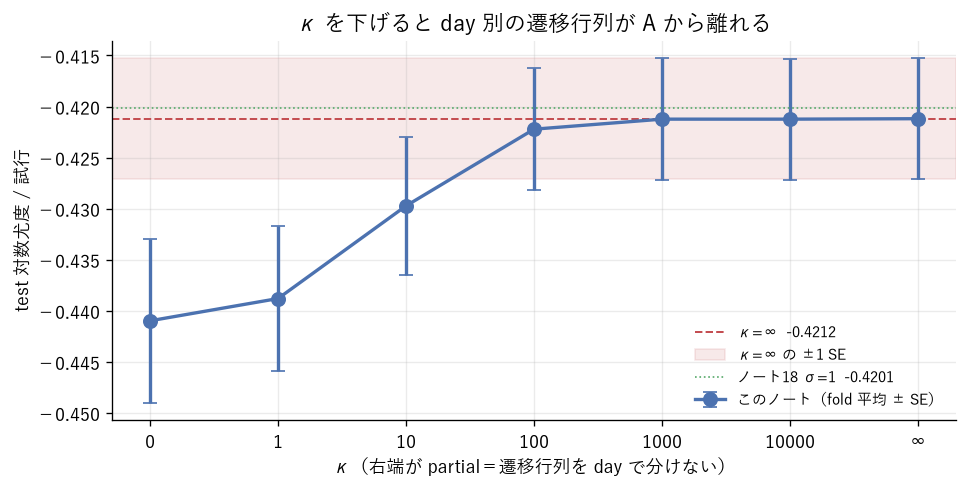

In [7]:
def kappa_table(test_mat):
    rows = []
    for i, lab in enumerate(KAPPA_LABELS):
        v = test_mat[:, i]
        rows.append({
            'kappa': lab,
            'test_ll': v.mean(),
            'se': v.std(ddof=0) / np.sqrt(FOLDS),
            'delta_vs_inf': v.mean() - test_mat[:, KAPPA_INDEX['inf']].mean(),
        })
    return pd.DataFrame(rows)


cv = kappa_table(test_mat)
print(cv.round(4).to_string(index=False))

x_pos = np.arange(len(KAPPA_LABELS))
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.errorbar(x_pos, cv['test_ll'], yerr=cv['se'], fmt='o-', color='#4c72b0',
            ms=8, lw=2, capsize=4, label='このノート（fold 平均 ± SE）')
inf_ll = float(cv.loc[cv['kappa'] == 'inf', 'test_ll'].iloc[0])
inf_se = float(cv.loc[cv['kappa'] == 'inf', 'se'].iloc[0])
ax.axhline(inf_ll, color='#c44e52', lw=1.2, ls='--', label=f'κ=∞  {inf_ll:+.4f}')
ax.axhspan(inf_ll - inf_se, inf_ll + inf_se, color='#c44e52', alpha=0.12, label='κ=∞ の ±1 SE')
ax.axhline(ll18.mean(), color='#55a868', lw=1, ls=':', label=f'ノート18 σ=1  {ll18.mean():+.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels([('∞' if k == 'inf' else k) for k in KAPPA_LABELS])
ax.set_xlabel('κ（右端が partial＝遷移行列を day で分けない）')
ax.set_ylabel('test 対数尤度 / 試行')
ax.set_title('κ を下げると day 別の遷移行列が A から離れる')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 5. 退化チェック

各 (fold, κ) の学習済みパラメータで、全試行に前向き後向きを1回回す。κ を選ぶ対象に残すのは、5 fold すべてで次を満たすものだけ。

- パラメータに NaN が無い
- day 別遷移行列の対角が 0.999 以上の行（吸収状態）が無い
- 試行数 30 以上の状態が、day 内位置の平均 0.25 未満または 0.75 超かつ sd 0.15 未満、になっていない（ノート17の時計解は 0.101±0.080）
- 14 day が同じ3分位の状態順に切られていない

In [8]:
def decode_params(P, pi, W):
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    with quiet():
        gamma = m.posterior_likelihood_of_each_state(P, pi, W, X, Y, np.ones(N), SESS)
    return gamma, gamma.argmax(axis=1), gamma.max(axis=1)


def degeneracy_one(P, pi, W):
    finite = bool(np.isfinite(P).all() and np.isfinite(pi).all() and np.isfinite(W).all())
    absorb_days = []
    if finite:
        for s in range(len(DAYS)):
            M = P[SESS[s]]
            if np.isnan(M).any():
                absorb_days.append(s)
            elif np.any(np.diag(M) >= ABSORB_DIAG):
                absorb_days.append(s)
    clock_states = []
    same_order = False
    pos_txt = []
    order = None
    if finite and not np.isnan(P).any():
        gamma, z, pmax = decode_params(P, pi, W)
        orders = []
        for k in range(K):
            chunks = []
            for s in range(len(DAYS)):
                sl = slice(SESS[s], SESS[s + 1])
                rel = np.linspace(0, 1, SESS[s + 1] - SESS[s], endpoint=False)
                chunks.append(rel[z[sl] == k])
            v = np.concatenate(chunks) if chunks else np.array([])
            if v.size == 0:
                pos_txt.append('n=0')
                continue
            pos_txt.append(f'{v.mean():.2f}±{v.std():.2f}')
            if v.size >= POS_MIN_N and (v.mean() < POS_MEAN_LO or v.mean() > POS_MEAN_HI) and v.std() < POS_SD_MAX:
                clock_states.append(k)
        for s in range(len(DAYS)):
            zi = z[SESS[s]:SESS[s + 1]]
            n = len(zi)
            cuts = [0, n // 3, 2 * n // 3, n]
            thirds = []
            for a, b in zip(cuts[:-1], cuts[1:]):
                if b > a:
                    thirds.append(int(np.bincount(zi[a:b], minlength=K).argmax()))
            orders.append(tuple(thirds))
        same_order = len(set(orders)) == 1 and len(set(orders[0])) > 1
        order = orders[0] if orders else None
    else:
        z = pmax = None
    ok = finite and not absorb_days and not clock_states and not same_order
    return dict(ok=ok, finite=finite, n_absorb_days=len(absorb_days),
                clock_states=clock_states, same_order=same_order,
                pos=' / '.join(pos_txt), order=order, z=z, pmax=pmax)


NB19.setdefault('degen', {})
rows = []
for i, lab in enumerate(KAPPA_LABELS):
    fold_ok = []
    for f in range(FOLDS):
        ck = f'{f}:{lab}'
        if ck not in NB19['degen']:
            packed = NB19['dyn_folds'][str(f)]
            NB19['degen'][ck] = degeneracy_one(packed['allP'][i], packed['allpi'][i], packed['allW'][i])
            # 系列そのものは大きいのでキャッシュから落とす（再計算は前向き1回）
            NB19['degen'][ck] = {k: v for k, v in NB19['degen'][ck].items() if k not in ('z', 'pmax')}
            save_cache()
        d = NB19['degen'][ck]
        fold_ok.append(d['ok'])
        rows.append({
            'kappa': lab, 'fold': f, 'pass': d['ok'], 'finite': d['finite'],
            'absorb_days': d['n_absorb_days'], 'clock': ','.join(map(str, d['clock_states'])) or '—',
            'same_order': d['same_order'], 'pos': d['pos'],
        })
    print(f'κ={lab:>5}  通過 {sum(fold_ok)}/{FOLDS}')

degen_df = pd.DataFrame(rows)
print(degen_df.drop(columns='pos').to_string(index=False))
print('状態別の day 内位置（fold 0）:')
print(degen_df[degen_df['fold'] == 0][['kappa', 'pos']].to_string(index=False))

κ=    0  通過 0/5
κ=    1  通過 2/5
κ=   10  通過 3/5
κ=  100  通過 5/5
κ= 1000  通過 5/5
κ=10000  通過 5/5
κ=  inf  通過 5/5
kappa  fold  pass  finite  absorb_days clock  same_order
    0     0 False    True            3     —       False
    0     1 False    True            3     —       False
    0     2 False    True            4     —       False
    0     3 False    True            5     —       False
    0     4 False    True            5     —       False
    1     0  True    True            0     —       False
    1     1  True    True            0     —       False
    1     2 False    True            4     —       False
    1     3 False    True            2     —       False
    1     4 False    True            3     —       False
   10     0  True    True            0     —       False
   10     1  True    True            0     —       False
   10     2 False    True            1     —       False
   10     3  True    True            0     —       False
   10     4 False    True        

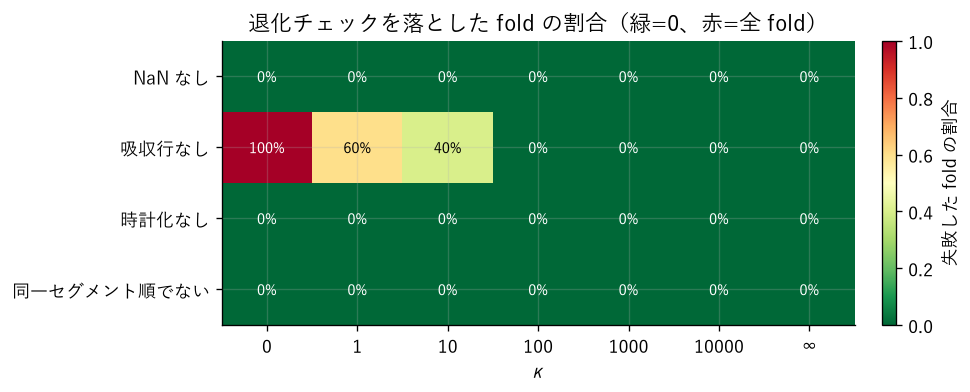

選択候補（全 fold 通過）: ['100', '1000', '10000', 'inf']
選択: κ=inf  test LL -0.4212 ± 0.0059  （κ=∞ との差 +0.0000）


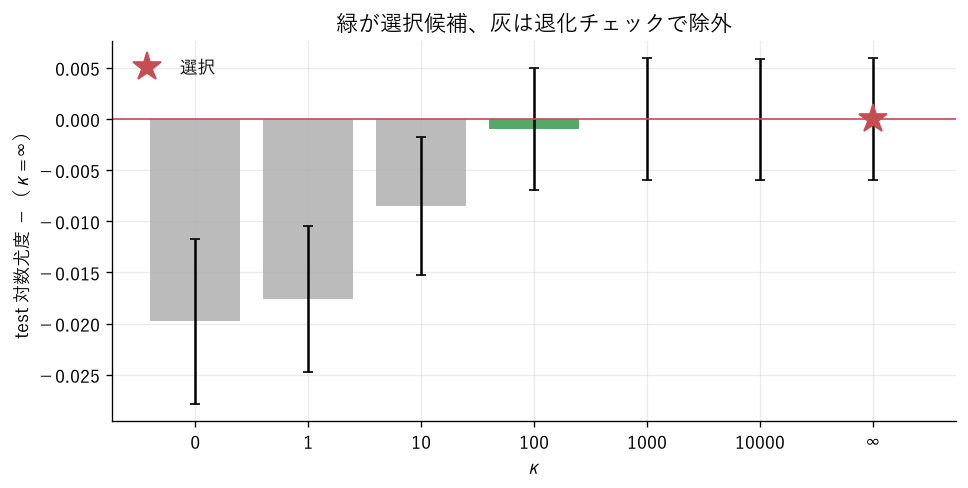

In [9]:
checks = ['finite', 'no_absorb', 'no_clock', 'no_same_order']
check_labels = ['NaN なし', '吸収行なし', '時計化なし', '同一セグメント順でない']
frac_fail = np.zeros((len(checks), len(KAPPA_LABELS)))
for i, lab in enumerate(KAPPA_LABELS):
    sub = degen_df[degen_df['kappa'] == lab]
    frac_fail[0, i] = (~sub['finite']).mean()
    frac_fail[1, i] = (sub['absorb_days'] > 0).mean()
    frac_fail[2, i] = (sub['clock'] != '—').mean()
    frac_fail[3, i] = sub['same_order'].mean()

fig, ax = plt.subplots(figsize=(8.2, 3.4))
im = ax.imshow(frac_fail, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(KAPPA_LABELS)))
ax.set_xticklabels([('∞' if k == 'inf' else k) for k in KAPPA_LABELS])
ax.set_yticks(range(len(checks)))
ax.set_yticklabels(check_labels)
ax.set_xlabel('κ')
ax.set_title('退化チェックを落とした fold の割合（緑=0、赤=全 fold）')
for i in range(frac_fail.shape[0]):
    for j in range(frac_fail.shape[1]):
        ax.text(j, i, f'{frac_fail[i, j]:.0%}', ha='center', va='center', fontsize=9,
                color='black' if 0.2 < frac_fail[i, j] < 0.8 else 'white')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='失敗した fold の割合')
fig.tight_layout()
plt.show()

eligible = []
for lab in KAPPA_LABELS:
    sub = degen_df[degen_df['kappa'] == lab]
    if bool(sub['pass'].all()):
        eligible.append(lab)
print('選択候補（全 fold 通過）:', eligible if eligible else '(なし)')

if not eligible:
    raise RuntimeError('退化チェックを通った κ が無い。グリッドか判定閾値を見直す。')

cand = cv[cv['kappa'].isin(eligible)]
best_row = cand.loc[cand['test_ll'].idxmax()]
KAPPA_BEST = str(best_row['kappa'])
print(f'選択: κ={KAPPA_BEST}  test LL {best_row["test_ll"]:+.4f} ± {best_row["se"]:.4f}'
      f'  （κ=∞ との差 {best_row["delta_vs_inf"]:+.4f}）')
NB19['kappa_best'] = KAPPA_BEST
NB19['eligible'] = eligible
save_cache()

fig, ax = plt.subplots(figsize=(8.2, 4.2))
colors = ['#55a868' if k in eligible else '#bbbbbb' for k in KAPPA_LABELS]
ax.bar(x_pos, cv['test_ll'] - inf_ll, color=colors, yerr=cv['se'], capsize=3)
ax.axhline(0, color='#c44e52', lw=1)
ax.set_xticks(x_pos)
ax.set_xticklabels([('∞' if k == 'inf' else k) for k in KAPPA_LABELS])
ax.set_ylabel('test 対数尤度 −（κ=∞）')
ax.set_xlabel('κ')
ax.set_title('緑が選択候補、灰は退化チェックで除外')
sel = KAPPA_LABELS.index(KAPPA_BEST)
ax.plot(sel, cv['test_ll'].iloc[sel] - inf_ll, marker='*', ms=18, color='#c44e52', linestyle='None', label='選択')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. 全データでの最終フィット

κ=∞ はノート18の全データ `'partial'`（行正規化した \(A\)）を使う。有限の κ は、∞ から降順に温スタートし、選ばれた κ に着いたところで止める。それより小さい κ は学習しない。

In [10]:
def fit_dynamic_point(present, initP, initpi, initW, alpha, A):
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    with quiet():
        p, pi, w, ll = m.fit(
            X, Y, present, initP, initpi, initW,
            sigma=reshapeSigma(SIGMA, K, D), alpha=alpha, A=A, sessInd=SESS,
            maxIter=DYN_MAXITER, tol=DYN_TOL, model_type='dynamic',
            L2penaltyW=0, priorDirP=None, fit_init_states=False)
    ll = ll[ll != 0]
    return p, pi, w, float(ll[-1]), int(len(ll))


p_inf, pi_inf, w_inf = NB18['final_fixed']['par']
A_full = as_global_P(p_inf)
print('全データ partial の行和（正規化前）:', np.round(np.asarray(p_inf[0], float).sum(1), 5))
print('正規化後の対角:', np.round(np.diag(A_full), 3))

NB19.setdefault('final_chain', {})
present_all = np.ones(N)
# 降順。∞ の次から選択 κ まで。
desc = [str(a) for a in ALPHA_LIST[::-1]]
if KAPPA_BEST == 'inf':
    stop_at = []
else:
    stop_at = desc[:desc.index(KAPPA_BEST) + 1]

chain_P = reshapeP_M1_to_M2(A_full, N)
chain_pi = np.full(K, 1.0 / K)
chain_W = np.array(w_inf, copy=True)
t0 = time.time()
for lab in stop_at:
    if lab in NB19['final_chain']:
        chain_P = NB19['final_chain'][lab]['p']
        chain_pi = NB19['final_chain'][lab]['pi']
        chain_W = NB19['final_chain'][lab]['w']
        print(f'[cache] final κ={lab}  train LL {NB19["final_chain"][lab]["ll_train"]:.2f}')
        continue
    alpha = float(lab)
    print(f'final κ={lab} を学習...')
    chain_P, chain_pi, chain_W, ll_tr, n_iter = fit_dynamic_point(
        present_all, chain_P, chain_pi, chain_W, alpha, A_full)
    NB19['final_chain'][lab] = dict(p=chain_P, pi=chain_pi, w=chain_W, ll_train=ll_tr, n_iter=n_iter)
    save_cache()
    print(f'  κ={lab}: train LL {ll_tr:.2f}  iters {n_iter}  ({time.time()-t0:.0f}s)')

if KAPPA_BEST == 'inf':
    final_P, final_pi, final_W = reshapeP_M1_to_M2(A_full, N), np.full(K, 1.0 / K), np.array(w_inf, copy=True)
else:
    rec = NB19['final_chain'][KAPPA_BEST]
    final_P, final_pi, final_W = rec['p'], rec['pi'], rec['w']
print('最終パラメータ NaN:', not (np.isfinite(final_P).all() and np.isfinite(final_W).all()))

全データ partial の行和（正規化前）: [0.99931 0.9999  0.99806]
正規化後の対角: [0.955 0.984 0.919]
最終パラメータ NaN: False


## 7. 選ばれた κ の状態構造

上段は day を 0–1 に揃えた MAP 状態（全日が同じ色の帯に割れていないかを見る）。下段は占有率。右はノート18と同じ要約数。

[κ=inf]
  1状態が90%以上のday: 6/14  (最頻状態占有率の中央値 0.759)
  day内の状態切り替え: 合計 29 回 / day中央値 1  / day別 [4, 1, 0, 1, 1, 0, 3, 1, 1, 2, 6, 0, 6, 3]
  state run長: 中央値 32 試行 / 最大 244
  p_max 平均 0.710 / P(z)>=0.8 残存率 0.333
  day内の正規化位置（状態別 平均±sd）:
    state 0: n= 455  pos 0.505 ± 0.314
    state 1: n=1794  pos 0.485 ± 0.278
    state 2: n= 110  pos 0.655 ± 0.297
  |W| の最大 2.67



findfont: Failed to find font weight normal, now using 500.


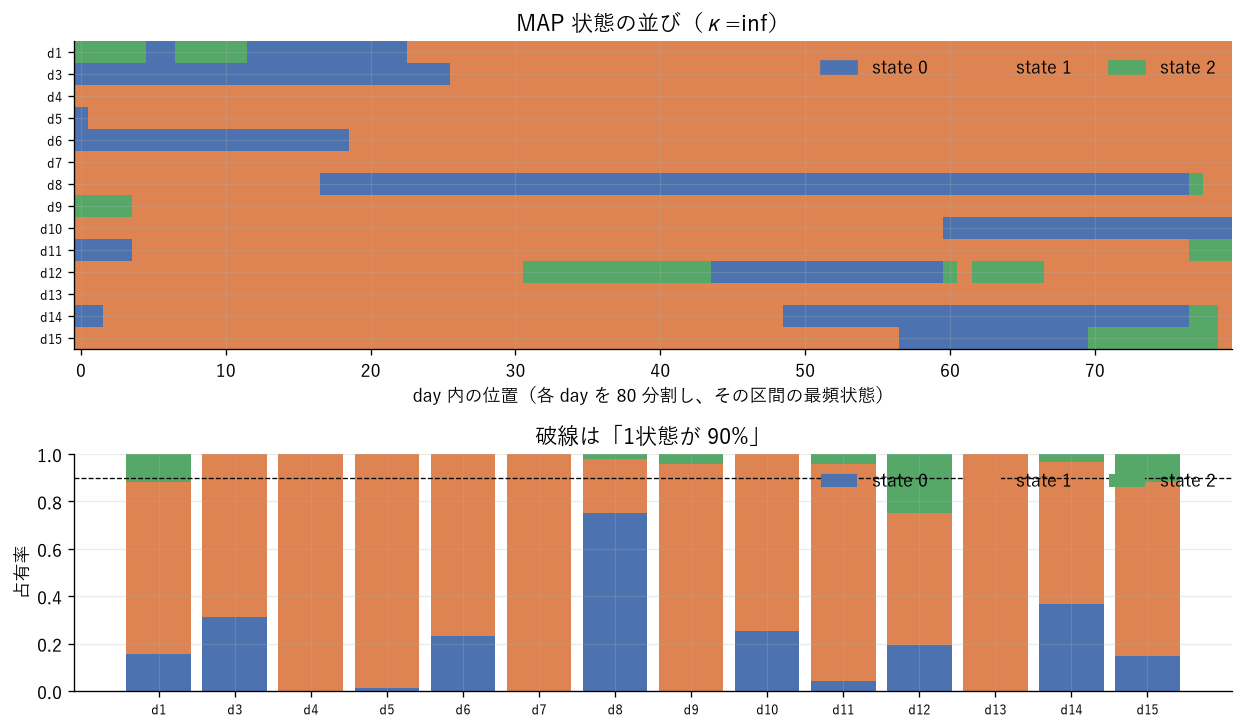

In [11]:
def state_summary(P, pi, W, label):
    gamma, z, pmax = decode_params(P, pi, W)
    occ = np.zeros((len(DAYS), K))
    switches, runs = [], []
    pos_by_state = [[] for _ in range(K)]
    for i in range(len(DAYS)):
        sl = slice(SESS[i], SESS[i + 1])
        zi = z[sl]
        for k in range(K):
            occ[i, k] = (zi == k).mean()
        switches.append(int((np.diff(zi) != 0).sum()))
        cut = np.flatnonzero(np.diff(zi) != 0) + 1
        runs += [len(s) for s in np.split(zi, cut)]
        rel = np.linspace(0, 1, len(zi), endpoint=False)
        for k in range(K):
            pos_by_state[k].append(rel[zi == k])
    dom = occ.max(axis=1)
    print(f'[{label}]')
    print(f'  1状態が90%以上のday: {int((dom >= 0.9).sum())}/{len(DAYS)}'
          f'  (最頻状態占有率の中央値 {np.median(dom):.3f})')
    print(f'  day内の状態切り替え: 合計 {sum(switches)} 回 / day中央値 {int(np.median(switches))}'
          f'  / day別 {switches}')
    print(f'  state run長: 中央値 {int(np.median(runs))} 試行 / 最大 {max(runs)}')
    print(f'  p_max 平均 {pmax.mean():.3f} / P(z)>={P_THRESHOLD} 残存率 {(pmax >= P_THRESHOLD).mean():.3f}')
    print('  day内の正規化位置（状態別 平均±sd）:')
    for k in range(K):
        v = np.concatenate(pos_by_state[k]) if pos_by_state[k] else np.array([])
        desc = f'{v.mean():.3f} ± {v.std():.3f}' if v.size else 'n/a'
        print(f'    state {k}: n={int((z == k).sum()):4d}  pos {desc}')
    wmax = np.abs(W[:, :, :, 1]).max()
    print(f'  |W| の最大 {wmax:.2f}')
    print()
    return dict(gamma=gamma, z=z, pmax=pmax, occ=occ, switches=np.array(switches), dom=dom)


sm = state_summary(final_P, final_pi, final_W, f'κ={KAPPA_BEST}')

BINS = 80
raster = np.full((len(DAYS), BINS), np.nan)
for i in range(len(DAYS)):
    zi = sm['z'][SESS[i]:SESS[i + 1]]
    for b in range(BINS):
        a = int(b / BINS * len(zi))
        c = int((b + 1) / BINS * len(zi))
        chunk = zi[a:max(c, a + 1)]
        raster[i, b] = np.bincount(chunk, minlength=K).argmax()

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2), sharex=False,
                         gridspec_kw={'height_ratios': [1.3, 1]})
ax = axes[0]
cmap = plt.matplotlib.colors.ListedColormap(STATE_COLORS)
ax.imshow(raster, aspect='auto', cmap=cmap, vmin=-0.5, vmax=K - 0.5, interpolation='nearest')
ax.set_yticks(range(len(DAYS)))
ax.set_yticklabels(DAY_LABELS, fontsize=8)
ax.set_xlabel('day 内の位置（各 day を 80 分割し、その区間の最頻状態）')
ax.set_title(f'MAP 状態の並び（κ={KAPPA_BEST}）')
handles = [plt.matplotlib.patches.Patch(color=STATE_COLORS[k], label=f'state {k}') for k in range(K)]
ax.legend(handles=handles, frameon=False, ncol=K, loc='upper right')

ax = axes[1]
bottom = np.zeros(len(DAYS))
for k in range(K):
    ax.bar(np.arange(len(DAYS)), sm['occ'][:, k], bottom=bottom, color=STATE_COLORS[k], width=0.85, label=f'state {k}')
    bottom += sm['occ'][:, k]
ax.axhline(0.9, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel('占有率')
ax.set_title('破線は「1状態が 90%」')
ax.legend(frameon=False, ncol=K, loc='upper right')
fig.tight_layout()
plt.show()

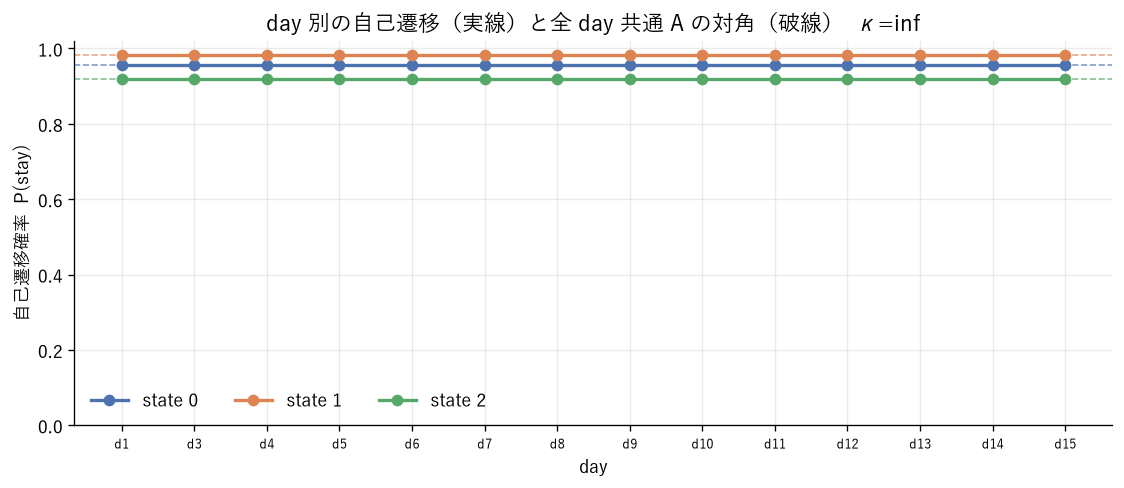

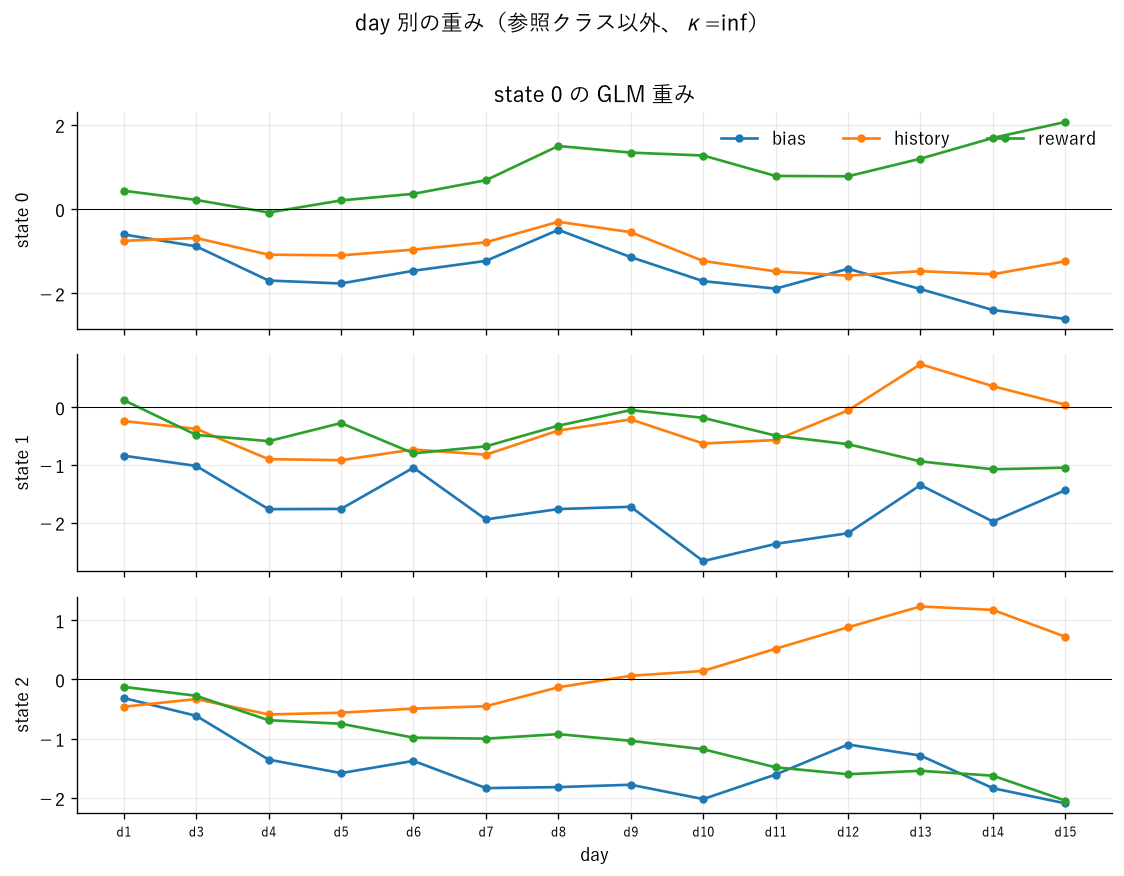

In [12]:
def session_diag(P):
    diag = np.zeros((len(DAYS), K))
    for s in range(len(DAYS)):
        diag[s] = np.diag(P[SESS[s]])
    return diag


diag = session_diag(final_P)
A_diag = np.diag(A_full)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for k in range(K):
    ax.plot(range(len(DAYS)), diag[:, k], 'o-', color=STATE_COLORS[k], lw=2, ms=6, label=f'state {k}')
    ax.axhline(A_diag[k], color=STATE_COLORS[k], lw=1, ls='--', alpha=0.7)
ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylim(0, 1.02)
ax.set_ylabel('自己遷移確率  P(stay)')
ax.set_xlabel('day')
ax.set_title(f'day 別の自己遷移（実線）と全 day 共通 A の対角（破線）  κ={KAPPA_BEST}')
ax.legend(frameon=False, ncol=K)
fig.tight_layout()
plt.show()

w_names = ['bias', 'history', 'reward']
Wday = np.zeros((len(DAYS), K, D))
for s in range(len(DAYS)):
    Wday[s] = final_W[SESS[s], :, :, 1]

fig, axes = plt.subplots(K, 1, figsize=(9.5, 7.2), sharex=True)
for k in range(K):
    ax = axes[k]
    for d in range(D):
        ax.plot(range(len(DAYS)), Wday[:, k, d], 'o-', ms=4, lw=1.6, label=w_names[d])
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel(f'state {k}')
    ax.set_title(f'state {k} の GLM 重み' if k == 0 else None)
    if k == 0:
        ax.legend(frameon=False, ncol=3, loc='upper right')
axes[-1].set_xticks(range(len(DAYS)))
axes[-1].set_xticklabels(DAY_LABELS, fontsize=8)
axes[-1].set_xlabel('day')
fig.suptitle(f'day 別の重み（参照クラス以外、κ={KAPPA_BEST}）', y=1.01)
fig.tight_layout()
plt.show()

## 8. 皮質デコードに使える試行数

\(P(z)\ge 0.8\) を残し、day 内で状態×試行タイプの最少セルを K 倍した数を「バランシング後に使える試行」とする（ノート18と同じ定義）。

P(z)>=0.8 残存率 0.333
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      16         0                0
 task-day3    156      35         0                0
 task-day4    103       0         0                0
 task-day5    183       0         0                0
 task-day6    318     163         0                0
 task-day7    157      85         0                0
 task-day8    153      83         0                0
 task-day9     72       0         0                0
task-day10    155      79         0                0
task-day11    233      16         0                0
task-day12    233     109         3               36
task-day13    126      39         0                0
task-day14    231      52         0                0
task-day15    163     108         0                0
balanced 使用可能試行: 全 day 計 36 / min_cell=0 の day 13/14


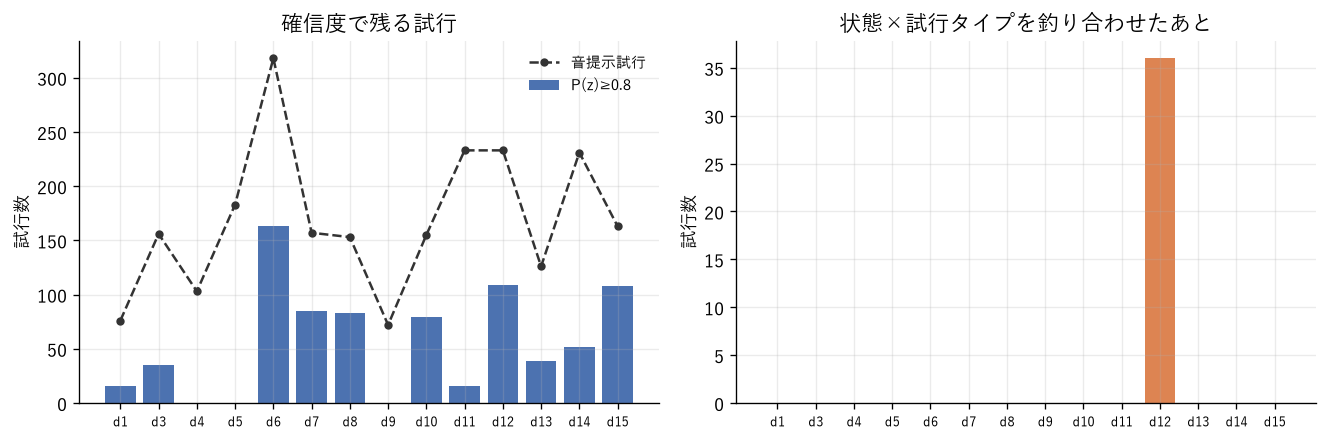

In [13]:
def balancing_table(sm):
    t2 = tr.copy()
    t2['state'] = sm['z']
    t2['p_max'] = sm['pmax']
    kept = t2[t2['p_max'] >= P_THRESHOLD]
    rows = []
    for d in DAYS:
        g = kept[kept['task_day'] == d]
        ct = pd.crosstab(g['trial_type'], g['state'])
        ct = ct.reindex(index=SOUND_TYPES, columns=range(K), fill_value=0)
        rows.append({
            'task_day': d,
            'n_all': int((t2['task_day'] == d).sum()),
            'n_kept': len(g),
            'min_cell': int(ct.values.min()),
            'usable_balanced': int((ct.min(axis=1) * K).sum()),
        })
    return pd.DataFrame(rows)


bal = balancing_table(sm)
print(f'P(z)>={P_THRESHOLD} 残存率 {(sm["pmax"] >= P_THRESHOLD).mean():.3f}')
print(bal.to_string(index=False))
print(f'balanced 使用可能試行: 全 day 計 {int(bal["usable_balanced"].sum())} / '
      f'min_cell=0 の day {int((bal["min_cell"] == 0).sum())}/{len(bal)}')

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
ax = axes[0]
ax.bar(range(len(DAYS)), bal['n_kept'], color='#4c72b0', label=f'P(z)≥{P_THRESHOLD}')
ax.plot(range(len(DAYS)), bal['n_all'], 'o--', color='#333333', ms=4, label='音提示試行')
ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylabel('試行数')
ax.set_title('確信度で残る試行')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.bar(range(len(DAYS)), bal['usable_balanced'], color='#dd8452')
ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylabel('試行数')
ax.set_title('状態×試行タイプを釣り合わせたあと')
fig.tight_layout()
plt.show()

## 9. 読み方

κ=∞ との差が SE より小さく、かつ退化チェックを通っているなら、day 別の遷移行列を入れても予測はほとんど増えない。自己遷移の実線が破線（共通の \(A\)）から系統的に離れていれば、その day の遷移はデータに引かれている。実線が破線に張り付いた状態は、その day にほとんど現れず \(A\) に戻っている。

K=2 はここでは走らせない。K=3 の選択と上の図を見てから別セクションにする。

In [14]:
print('=' * 72)
print(f'選択 κ = {KAPPA_BEST}   候補 = {eligible}')
print(cv.round(4).to_string(index=False))
print(f'1状態≥90% の day: {int((sm["dom"] >= 0.9).sum())}/{len(DAYS)}')
print(f'切り替え合計 {int(sm["switches"].sum())} / P(z)≥{P_THRESHOLD} {(sm["pmax"] >= P_THRESHOLD).mean():.3f}')
print(f'balanced 試行 {int(bal["usable_balanced"].sum())}')
print('=' * 72)

選択 κ = inf   候補 = ['100', '1000', '10000', 'inf']
kappa  test_ll     se  delta_vs_inf
    0  -0.4410 0.0080       -0.0198
    1  -0.4388 0.0071       -0.0176
   10  -0.4297 0.0067       -0.0085
  100  -0.4222 0.0060       -0.0010
 1000  -0.4212 0.0060       -0.0000
10000  -0.4212 0.0059       -0.0000
  inf  -0.4212 0.0059        0.0000
1状態≥90% の day: 6/14
切り替え合計 29 / P(z)≥0.8 0.333
balanced 試行 36
